In [2]:
import pandas as pd, sqlite3
sales = pd.read_csv("sales_week.csv"); sales["revenue"] = sales["qty"] * sales["price"]
conn = sqlite3.connect("stall.db")
sales.to_sql("sales", conn, if_exists="replace", index=False)
def run(sql): return pd.read_sql(sql, conn)


In [3]:
run("""
    SELECT fruit, revenue
    FROM sales
    WHERE revenue > (SELECT AVG(revenue) FROM sales)
""")


,fruit,revenue
0,orange,400
1,grape,700
2,apple,450
3,grape,1000
4,orange,380
5,apple,540
6,grape,1050
7,orange,420
8,apple,510
9,mango,720


In [4]:
run("""
    SELECT *
    FROM sales
    WHERE revenue > (
        SELECT AVG(revenue)
        FROM sales
    )
""")

,date,stall,fruit,category,qty,price,revenue
0,2024-06-03,South,orange,citrus,20,20,400
1,2024-06-03,South,grape,berry,14,50,700
2,2024-06-04,North,apple,pome,15,30,450
3,2024-06-04,South,grape,berry,20,50,1000
4,2024-06-05,North,orange,citrus,19,20,380
5,2024-06-05,North,apple,pome,18,30,540
6,2024-06-05,South,grape,berry,21,50,1050
7,2024-06-06,North,orange,citrus,21,20,420
8,2024-06-06,North,apple,pome,17,30,510
9,2024-06-06,North,mango,tropical,18,40,720


In [5]:
run("""
    SELECT *
    FROM sales
    WHERE qty > (
        SELECT AVG(qty)
        FROM sales
    )
""")

,date,stall,fruit,category,qty,price,revenue
0,2024-06-03,North,orange,citrus,18,20,360
1,2024-06-03,South,orange,citrus,20,20,400
2,2024-06-03,South,grape,berry,14,50,700
3,2024-06-04,North,apple,pome,15,30,450
4,2024-06-04,South,grape,berry,20,50,1000
5,2024-06-04,South,orange,citrus,18,20,360
6,2024-06-05,North,lemon,citrus,15,15,225
7,2024-06-05,North,orange,citrus,19,20,380
8,2024-06-05,North,apple,pome,18,30,540
9,2024-06-05,South,grape,berry,21,50,1050


In [6]:
run("""
    SELECT *
    FROM sales
    WHERE price = (
        SELECT MAX(price)
        FROM sales
    )
""")

,date,stall,fruit,category,qty,price,revenue
0,2024-06-03,North,grape,berry,6,50,300
1,2024-06-03,South,grape,berry,14,50,700
2,2024-06-04,North,grape,berry,4,50,200
3,2024-06-04,South,grape,berry,20,50,1000
4,2024-06-05,North,grape,berry,5,50,250
5,2024-06-05,South,grape,berry,21,50,1050
6,2024-06-06,North,grape,berry,4,50,200
7,2024-06-06,South,grape,berry,23,50,1150
8,2024-06-07,South,grape,berry,4,50,200
9,2024-06-08,North,grape,berry,15,50,750


In [7]:
#2
run("""
    WITH fruit_totals AS (
        SELECT fruit, SUM(revenue) AS total
        FROM sales
        GROUP BY fruit
    )
    SELECT * FROM fruit_totals
    WHERE total > 3000
    ORDER BY total DESC
""")


,fruit,total
0,grape,6650
1,mango,5760
2,orange,3220


In [8]:
run("""
    WITH avg_sale AS (
        SELECT AVG(revenue) AS avg_rev
        FROM sales
    )
    SELECT *
    FROM sales
    WHERE revenue > (SELECT avg_rev FROM avg_sale)
""")

,date,stall,fruit,category,qty,price,revenue
0,2024-06-03,South,orange,citrus,20,20,400
1,2024-06-03,South,grape,berry,14,50,700
2,2024-06-04,North,apple,pome,15,30,450
3,2024-06-04,South,grape,berry,20,50,1000
4,2024-06-05,North,orange,citrus,19,20,380
5,2024-06-05,North,apple,pome,18,30,540
6,2024-06-05,South,grape,berry,21,50,1050
7,2024-06-06,North,orange,citrus,21,20,420
8,2024-06-06,North,apple,pome,17,30,510
9,2024-06-06,North,mango,tropical,18,40,720


In [9]:
run("""
    WITH stall_totals AS (
        SELECT stall,
               SUM(revenue) AS total
        FROM sales
        GROUP BY stall
    )
    SELECT *
    FROM stall_totals
    ORDER BY total DESC
    LIMIT 1
""")

,stall,total
0,South,10955


In [10]:
run("""
    SELECT fruit, revenue,
           SUM(revenue) OVER (PARTITION BY fruit) AS fruit_total
    FROM sales
""")

,fruit,revenue,fruit_total
0,apple,450,2580
1,apple,90,2580
2,apple,540,2580
3,apple,510,2580
4,apple,630,2580
5,apple,360,2580
6,banana,120,820
7,banana,130,820
8,banana,150,820
9,banana,100,820


In [11]:
run("""
    SELECT fruit,
           revenue,
           SUM(revenue) OVER (PARTITION BY fruit) AS fruit_total
    FROM sales
""")

,fruit,revenue,fruit_total
0,apple,450,2580
1,apple,90,2580
2,apple,540,2580
3,apple,510,2580
4,apple,630,2580
5,apple,360,2580
6,banana,120,820
7,banana,130,820
8,banana,150,820
9,banana,100,820


In [12]:
run("""
    SELECT fruit,
           revenue,
           ROUND(
               revenue * 100.0 /
               SUM(revenue) OVER (PARTITION BY fruit),
               2
           ) AS revenue_percent
    FROM sales
""")

,fruit,revenue,revenue_percent
0,apple,450,17.44
1,apple,90,3.49
2,apple,540,20.93
3,apple,510,19.77
4,apple,630,24.42
5,apple,360,13.95
6,banana,120,14.63
7,banana,130,15.85
8,banana,150,18.29
9,banana,100,12.20


In [13]:
run("""
    WITH t AS (
        SELECT stall, fruit, SUM(revenue) AS total
        FROM sales GROUP BY stall, fruit
    )
    SELECT stall, fruit, total,
           ROW_NUMBER() OVER (PARTITION BY stall ORDER BY total DESC) AS rank
    FROM t
""")


,stall,fruit,total,rank
0,North,mango,2800,1
1,North,apple,2130,2
2,North,grape,1700,3
3,North,orange,1640,4
4,North,lemon,675,5
5,North,banana,330,6
6,South,grape,4950,1
7,South,mango,2960,2
8,South,orange,1580,3
9,South,lemon,525,4


In [14]:
run("""
    WITH totals AS (
        SELECT stall,
               fruit,
               SUM(revenue) AS total
        FROM sales
        GROUP BY stall, fruit
    )
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY stall
               ORDER BY total DESC
           ) AS rank
    FROM totals
""")

,stall,fruit,total,rank
0,North,mango,2800,1
1,North,apple,2130,2
2,North,grape,1700,3
3,North,orange,1640,4
4,North,lemon,675,5
5,North,banana,330,6
6,South,grape,4950,1
7,South,mango,2960,2
8,South,orange,1580,3
9,South,lemon,525,4


In [15]:
run("""
    WITH totals AS (
        SELECT category,
               fruit,
               SUM(revenue) AS total
        FROM sales
        GROUP BY category, fruit
    )
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY category
               ORDER BY total DESC
           ) AS rank
    FROM totals
""")

,category,fruit,total,rank
0,berry,grape,6650,1
1,citrus,orange,3220,1
2,citrus,lemon,1200,2
3,pome,apple,2580,1
4,tropical,mango,5760,1
5,tropical,banana,820,2


In [16]:
#5
run("""
    WITH ranked AS (
        SELECT stall, fruit, SUM(revenue) AS total,
               ROW_NUMBER() OVER (PARTITION BY stall ORDER BY SUM(revenue) DESC) AS rank
        FROM sales GROUP BY stall, fruit
    )
    SELECT stall, fruit, total
    FROM ranked
    WHERE rank <= 2
""")


,stall,fruit,total
0,North,mango,2800
1,North,apple,2130
2,South,grape,4950
3,South,mango,2960


In [17]:
run("""
    WITH ranked AS (
        SELECT stall,
               fruit,
               SUM(revenue) AS total,
               ROW_NUMBER() OVER (
                   PARTITION BY stall
                   ORDER BY SUM(revenue) DESC
               ) AS rank
        FROM sales
        GROUP BY stall, fruit
    )
    SELECT stall,
           fruit,
           total
    FROM ranked
    WHERE rank <= 2
""")

,stall,fruit,total
0,North,mango,2800
1,North,apple,2130
2,South,grape,4950
3,South,mango,2960


In [18]:
run("""
    WITH ranked AS (
        SELECT category,
               fruit,
               SUM(revenue) AS total,
               ROW_NUMBER() OVER (
                   PARTITION BY category
                   ORDER BY SUM(revenue) DESC
               ) AS rank
        FROM sales
        GROUP BY category, fruit
    )
    SELECT category,
           fruit,
           total
    FROM ranked
    WHERE rank = 1
""")

,category,fruit,total
0,berry,grape,6650
1,citrus,orange,3220
2,pome,apple,2580
3,tropical,mango,5760


In [19]:
#6
run("""
    SELECT date,
           SUM(daily) OVER (ORDER BY date) AS running_total
    FROM (
        SELECT date, SUM(revenue) AS daily
        FROM sales GROUP BY date
    )
""")


,date,running_total
0,2024-06-03,1995
1,2024-06-04,4825
2,2024-06-05,8130
3,2024-06-06,11730
4,2024-06-07,14000
5,2024-06-08,17295
6,2024-06-09,20230


In [20]:
run("""
    SELECT date,
           daily,
           SUM(daily) OVER (
               ORDER BY date
           ) AS running_total
    FROM (
        SELECT date,
               SUM(revenue) AS daily
        FROM sales
        GROUP BY date
    )
""")

,date,daily,running_total
0,2024-06-03,1995,1995
1,2024-06-04,2830,4825
2,2024-06-05,3305,8130
3,2024-06-06,3600,11730
4,2024-06-07,2270,14000
5,2024-06-08,3295,17295
6,2024-06-09,2935,20230


In [21]:
run("""
    SELECT date,
           daily_qty,
           SUM(daily_qty) OVER (
               ORDER BY date
           ) AS running_qty
    FROM (
        SELECT date,
               SUM(qty) AS daily_qty
        FROM sales
        GROUP BY date
    )
""")

,date,daily_qty,running_qty
0,2024-06-03,67,67
1,2024-06-04,101,168
2,2024-06-05,123,291
3,2024-06-06,102,393
4,2024-06-07,77,470
5,2024-06-08,109,579
6,2024-06-09,107,686


In [22]:
#7
run("SELECT fruit, price, CASE WHEN price >= 40 THEN 'premium' ELSE 'regular' END AS tier FROM sales")
 


,fruit,price,tier
0,mango,40,premium
1,orange,20,regular
2,grape,50,premium
3,orange,20,regular
4,grape,50,premium
5,lemon,15,regular
6,apple,30,regular
7,lemon,15,regular
8,banana,10,regular
9,mango,40,premium


In [23]:
run("""
    SELECT
      SUM(CASE WHEN price >= 40 THEN revenue ELSE 0 END) AS premium_rev,
      SUM(CASE WHEN price <  40 THEN revenue ELSE 0 END) AS regular_rev
    FROM sales
""")


,premium_rev,regular_rev
0,12410,7820


In [24]:
run("""
    SELECT fruit,
           price,
           CASE
               WHEN price >= 40 THEN 'Premium'
               ELSE 'Regular'
           END AS tier
    FROM sales
""")

,fruit,price,tier
0,mango,40,Premium
1,orange,20,Regular
2,grape,50,Premium
3,orange,20,Regular
4,grape,50,Premium
5,lemon,15,Regular
6,apple,30,Regular
7,lemon,15,Regular
8,banana,10,Regular
9,mango,40,Premium


In [25]:
run("""
    SELECT
        SUM(
            CASE
                WHEN price >= 40 THEN revenue
                ELSE 0
            END
        ) AS premium_revenue,

        SUM(
            CASE
                WHEN price < 40 THEN revenue
                ELSE 0
            END
        ) AS regular_revenue
    FROM sales
""")

,premium_revenue,regular_revenue
0,12410,7820


<Axes: xlabel='fruit', ylabel='total'>

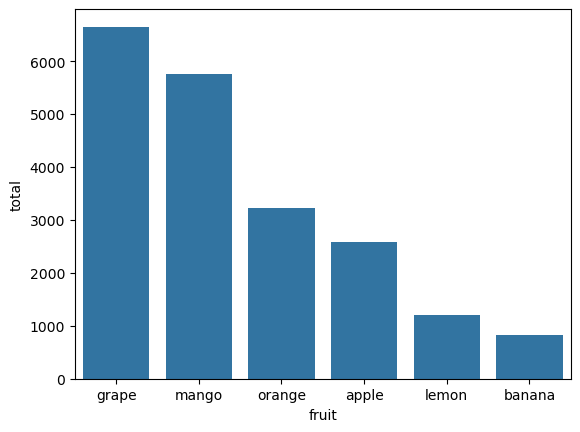

In [26]:
#8
summary = run("""
    SELECT fruit, SUM(revenue) AS total
    FROM sales GROUP BY fruit ORDER BY total DESC
""")
 
import seaborn as sns
sns.barplot(data=summary, x="fruit", y="total")  


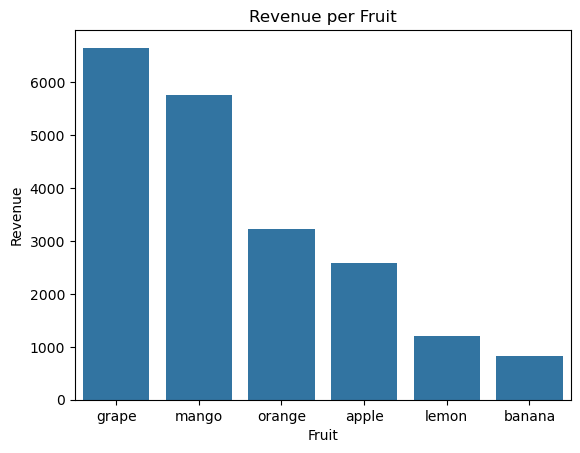

In [27]:
summary = run("""
    SELECT fruit,
           SUM(revenue) AS total
    FROM sales
    GROUP BY fruit
    ORDER BY total DESC
""")

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=summary, x="fruit", y="total")
plt.title("Revenue per Fruit")
plt.xlabel("Fruit")
plt.ylabel("Revenue")
plt.show()

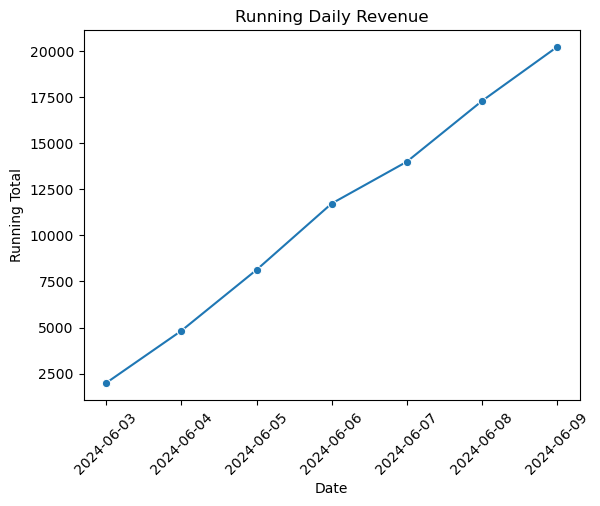

In [28]:
running = run("""
    SELECT date,
           SUM(daily) OVER (ORDER BY date) AS running_total
    FROM (
        SELECT date,
               SUM(revenue) AS daily
        FROM sales
        GROUP BY date
    )
""")

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=running, x="date", y="running_total", marker="o")
plt.title("Running Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Running Total")
plt.xticks(rotation=45)
plt.show()

In [34]:
#9
run("""
    SELECT *
    FROM sales
    WHERE revenue >
    (
        SELECT AVG(revenue)
        FROM sales
    )
""")

,date,stall,fruit,category,qty,price,revenue
0,2024-06-03,South,orange,citrus,20,20,400
1,2024-06-03,South,grape,berry,14,50,700
2,2024-06-04,North,apple,pome,15,30,450
3,2024-06-04,South,grape,berry,20,50,1000
4,2024-06-05,North,orange,citrus,19,20,380
5,2024-06-05,North,apple,pome,18,30,540
6,2024-06-05,South,grape,berry,21,50,1050
7,2024-06-06,North,orange,citrus,21,20,420
8,2024-06-06,North,apple,pome,17,30,510
9,2024-06-06,North,mango,tropical,18,40,720


In [35]:
run("""
    WITH fruit_totals AS (
        SELECT fruit,
               SUM(revenue) AS total
        FROM sales
        GROUP BY fruit
    )
    SELECT *
    FROM fruit_totals
    WHERE total > 3000
    ORDER BY total DESC
""")

,fruit,total
0,grape,6650
1,mango,5760
2,orange,3220


In [36]:
run("""
    WITH ranked AS (
        SELECT stall,
               fruit,
               SUM(revenue) AS total,
               ROW_NUMBER() OVER (
                   PARTITION BY stall
                   ORDER BY SUM(revenue) DESC
               ) AS rank
        FROM sales
        GROUP BY stall, fruit
    )
    SELECT stall,
           fruit,
           total
    FROM ranked
    WHERE rank <= 2
""")

,stall,fruit,total
0,North,mango,2800
1,North,apple,2130
2,South,grape,4950
3,South,mango,2960


In [37]:
run("""
    SELECT fruit,
           revenue,
           ROUND(
               revenue * 100.0 /
               SUM(revenue) OVER (PARTITION BY fruit),
               2
           ) AS revenue_percent
    FROM sales
""")

,fruit,revenue,revenue_percent
0,apple,450,17.44
1,apple,90,3.49
2,apple,540,20.93
3,apple,510,19.77
4,apple,630,24.42
5,apple,360,13.95
6,banana,120,14.63
7,banana,130,15.85
8,banana,150,18.29
9,banana,100,12.20


In [38]:
run("""
    SELECT date,
           daily,
           SUM(daily) OVER (
               ORDER BY date
           ) AS running_total
    FROM (
        SELECT date,
               SUM(revenue) AS daily
        FROM sales
        GROUP BY date
    )
""")

,date,daily,running_total
0,2024-06-03,1995,1995
1,2024-06-04,2830,4825
2,2024-06-05,3305,8130
3,2024-06-06,3600,11730
4,2024-06-07,2270,14000
5,2024-06-08,3295,17295
6,2024-06-09,2935,20230


In [39]:
run("""
    SELECT
        SUM(CASE WHEN price >= 40 THEN revenue ELSE 0 END) AS premium_revenue,
        SUM(CASE WHEN price < 40 THEN revenue ELSE 0 END) AS regular_revenue
    FROM sales
""")

,premium_revenue,regular_revenue
0,12410,7820


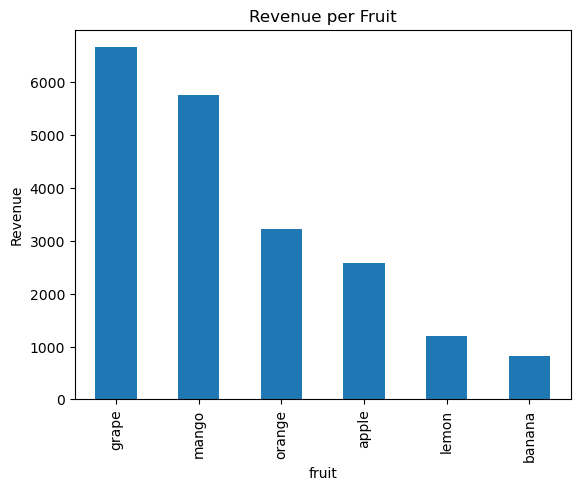

In [40]:
summary = run("""
    SELECT fruit,
           SUM(revenue) AS total
    FROM sales
    GROUP BY fruit
    ORDER BY total DESC
""")

import matplotlib.pyplot as plt

summary.plot(
    kind="bar",
    x="fruit",
    y="total",
    legend=False,
    title="Revenue per Fruit"
)

plt.ylabel("Revenue")
plt.show()

In [30]:
run("""
    WITH daily_sales AS (
        SELECT date,
               SUM(revenue) AS revenue
        FROM sales
        GROUP BY date
    )
    SELECT date,
           revenue,
           LAG(revenue) OVER (ORDER BY date) AS previous_day,
           revenue - LAG(revenue) OVER (ORDER BY date) AS day_change
    FROM daily_sales
""")

,date,revenue,previous_day,day_change
0,2024-06-03,1995,NaN,NaN
1,2024-06-04,2830,1995.0,835.0
2,2024-06-05,3305,2830.0,475.0
3,2024-06-06,3600,3305.0,295.0
4,2024-06-07,2270,3600.0,-1330.0
5,2024-06-08,3295,2270.0,1025.0
6,2024-06-09,2935,3295.0,-360.0


In [31]:
run("""
    WITH totals AS (
        SELECT fruit,
               SUM(revenue) AS total
        FROM sales
        GROUP BY fruit
    )
    SELECT fruit,
           total,
           ROW_NUMBER() OVER (ORDER BY total DESC) AS row_number,
           RANK() OVER (ORDER BY total DESC) AS rank,
           DENSE_RANK() OVER (ORDER BY total DESC) AS dense_rank
    FROM totals
""")

,fruit,total,row_number,rank,dense_rank
0,grape,6650,1,1,1
1,mango,5760,2,2,2
2,orange,3220,3,3,3
3,apple,2580,4,4,4
4,lemon,1200,5,5,5
5,banana,820,6,6,6


In [32]:
run("""
    WITH fruit_sales AS (
        SELECT stall,
               fruit,
               SUM(revenue) AS fruit_revenue
        FROM sales
        GROUP BY stall, fruit
    )
    SELECT stall,
           fruit,
           fruit_revenue,
           SUM(fruit_revenue) OVER (PARTITION BY stall) AS stall_total,
           ROUND(
               fruit_revenue * 100.0 /
               SUM(fruit_revenue) OVER (PARTITION BY stall),
               2
           ) AS revenue_share
    FROM fruit_sales
""")

,stall,fruit,fruit_revenue,stall_total,revenue_share
0,North,apple,2130,9275,22.96
1,North,banana,330,9275,3.56
2,North,grape,1700,9275,18.33
3,North,lemon,675,9275,7.28
4,North,mango,2800,9275,30.19
5,North,orange,1640,9275,17.68
6,South,apple,450,10955,4.11
7,South,banana,490,10955,4.47
8,South,grape,4950,10955,45.18
9,South,lemon,525,10955,4.79


In [33]:
run("""
    WITH clean AS (
        SELECT stall,
               fruit,
               SUM(revenue) AS total
        FROM sales
        GROUP BY stall, fruit
    ),
    ranked AS (
        SELECT stall,
               fruit,
               total,
               ROW_NUMBER() OVER (
                   PARTITION BY stall
                   ORDER BY total DESC
               ) AS rank
        FROM clean
    )
    SELECT *
    FROM ranked
    WHERE rank <= 2
""")

,stall,fruit,total,rank
0,North,mango,2800,1
1,North,apple,2130,2
2,South,grape,4950,1
3,South,mango,2960,2
